# Numerical Integration and Differentiation

examples

In [1]:
import numpy as np
from fractions import Fraction
from functools import reduce, lru_cache

from scipy import linalg as la
import scipy.optimize as opt
from scipy import special, interpolate, integrate
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
np.set_printoptions(suppress=True, precision=6)

def sign(x):
    s = np.sign(x)
    return s if s else 1


points = [] # trace function evaluations

In [2]:
def monomial_coef(nodes, b):
    A = np.vander(nodes, increasing=True)
    return la.solve(A, b)


def monomial_bases(nodes):
    return [Polynomial([0] * n + [1]) for n in range(len(nodes))]


def lagrange_bases(nodes):
    nodes = np.array(nodes, dtype=float)
    n = len(nodes)
    lx = [reduce(Polynomial.__mul__, [Polynomial([-a, 1])for a in nodes[np.arange(n) != i]]) for i in range(n)]
    wx = [1 / (nodes[i] - nodes[np.arange(n) != i]).prod() for i in range(n)]
    return [l * w for l, w in zip(lx, wx)]


def newton_bases(nodes):
    nodes = np.array(nodes, dtype=float)
    n = len(nodes)
    return [Polynomial([1])] + [reduce(Polynomial.__mul__, [Polynomial([-a, 1]) for a in nodes[:i+1]]) for i in range(n-1)]


def newton_coef_axb(nodes, b):
    nodes = np.array(nodes, dtype=float)
    ps = newton_bases(nodes)
    A = np.array([p(nodes) for p in ps]).T
    # print(np.linalg.cond(A))
    return la.solve(A, b)


def newton_incr(q, p, x, y):
    return (y - q(x)) / p(x)


def newton_coef_incr(nodes, b):
    ps = newton_bases(nodes)
    qs = [Polynomial([b[0]])]
    xs = [b[0]]
    for i in range(1, len(nodes)):
        xs.append(newton_incr(qs[-1], ps[i], nodes[i], b[i]))
        qs.append(qs[-1] + xs[-1] * ps[i])
    return np.array(xs)


def newton_coef_recur(nodes, b):

    @lru_cache
    def divided_difference(i, j):
        if i == j:
            return b[i]
        else:
            return (divided_difference(i+1, j) - divided_difference(i, j-1)) / (nodes[j] - nodes[i])
        
    return np.array([divided_difference(0, i) for i in range(len(nodes))])


def monomial_horner(coef, x):
    s = np.zeros_like(x) if isinstance(x, np.ndarray) else 0
    for a in coef[::-1][:-1]:
        s = (s + a) * x
    s += coef[0]
    return s


def newton_horner(coef, x, nodes):
    coef, nodes = coef[::-1], nodes[::-1]
    s = np.zeros_like(x) if isinstance(x, np.ndarray) else 0
    for a, t in zip(coef, nodes[1:]):
        s = (s + a) * (x - t)
    s += coef[-1]
    return s

In [3]:
def open_newton_cotes(a, b, n):
    return np.linspace(a, b, n+2)[1:-1]


def closed_newton_cotes(a, b, n):
    return np.linspace(a, b, n)


def midpoint(f, a, b):
    return (b - a) * f((a + b) / 2)


def trapezoid(f, a, b):
    return .5 * (b - a) * (f(a) + f(b))


def simpson(f, a, b):
    return 1 / 6 * (b - a) * (f(a) + 4 * f((a + b) / 2) + f(b))

0.7788007830714049
0.6839397205857212
0.7471804289095104
<class 'numpy.polynomial.polynomial.Polynomial'>


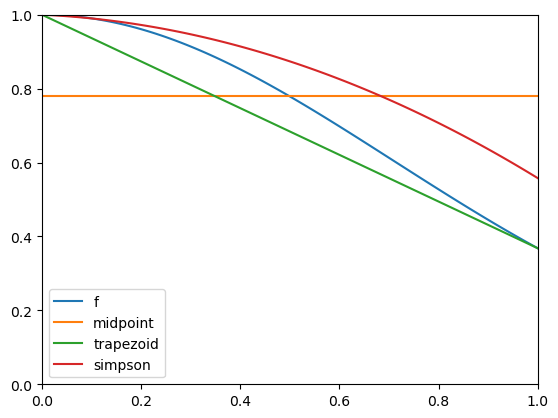

In [4]:
# 8.2
def f(x):
    return np.exp(- x ** 2)

print(midpoint(f, 0, 1))
print(trapezoid(f, 0, 1))
print(simpson(f, 0, 1))

pm = sum(w * p for w, p in zip(monomial_coef([.5], [f(.5)]), monomial_bases([.5])))
print(type(pm))
pt = sum(w * p for w, p in zip([f(0), f(1)], lagrange_bases([0, 1])))
ps = sum(w * p for w, p in zip(newton_coef_incr([0, .5, 1], [f(0), f(.5), f(1)]), newton_bases([0, .5, 1])))

x = np.linspace(0, 1, 101)
plt.plot(x, f(x), label='f')
plt.plot(x, monomial_horner(pm.coef, x), label='midpoint')
plt.plot(x, pt(x), label='trapezoid')
plt.plot(x, newton_horner(ps.coef, x, [0, .5, 1]), label='simpson')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()

In [5]:
# 8.3
im = Fraction(midpoint(np.square, 0, 1))
it = Fraction(trapezoid(np.square, 0, 1))
e = (it - im) / 3
print(im, it, e)

print(im * 2 / 3 + it / 3)
print(simpson(np.square, 0, 1))

1/4 1/2 1/12
1/3
0.3333333333333333


In [6]:
# Chebyshev extrema progressive
n = 10
n_roots = special.chebyu(n).roots

cnt = 0
for x in special.chebyu(2 * n + 1).roots:
    if np.abs(n_roots - x).min() > 1e-8:
        cnt += 1
cnt

11

In [7]:
# 8.4
def f(x):
    return np.array([
        x[0] + x[1] - 2,
        x[0] * x[2] + x[1] * x[3],
        x[0] * x[2] ** 2 + x[1] * x[3] ** 2 - 2 / 3,
        x[0] * x[2] ** 3 + x[1] * x[3] ** 3,
    ])


opt.root(f, [0, 0, 1, 1])

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00 -9.343e-13 -5.618e-12  1.562e-12]
       x: [ 1.000e+00  1.000e+00  5.774e-01 -5.774e-01]
  method: hybr
    nfev: 45
    fjac: [[-8.404e-01 -4.834e-01 -1.295e-01  2.082e-01]
           [-5.406e-01  7.331e-01  1.619e-01 -3.796e-01]
           [ 3.796e-02 -1.972e-01 -6.656e-01 -7.188e-01]
           [-5.497e-03  4.359e-01 -7.170e-01  5.440e-01]]
       r: [-1.190e+00 -4.970e-01 -4.606e-01 -3.195e-01 -1.077e+00
            6.321e-01  5.133e-01 -1.194e+00  4.052e-01  1.157e+00]
     qtf: [-3.983e-10  5.801e-10 -7.274e-10 -1.185e-09]

In [8]:
# gauss legendre quadrature
from numpy.polynomial import Legendre

Legendre.basis(2).roots()

array([-0.57735,  0.57735])

In [9]:
# 8.5
def standard_gauss_quad(f, n):
    if n == 2:
        return f(- 1 / np.sqrt(3)) + f(1 / np.sqrt(3))


def gauss_quad(f, a, b, n=2):
    return (b - a) / 2 * standard_gauss_quad(lambda x: f(((b - a) * x + a + b) / 2), n=n)


def f(x):
    return np.exp(- x ** 2)


gauss_quad(f, 0, 1)

np.float64(0.7465946882828598)

In [10]:
def forward_difference(f, x, h):
    return (f(x + h) - f(x)) / h


def backward_difference(f, x, h):
    return (f(x) - f(x - h)) / h


def central_difference(f, x, h):
    return (f(x + h) - f(x - h)) / 2 / h


def richardson_extrapolation(bigf, smallf, p, q):
    return bigf + (bigf - smallf) / (1 / q ** p - 1)

In [11]:
# 8.8
p, smallh, bigh = 1, .25, .5
bigf = forward_difference(np.sin, 1, bigh)
smallf = forward_difference(np.sin, 1, smallh)
extraf = richardson_extrapolation(bigf, smallf, p, q=2)
print(bigf, smallf, extraf)

0.3120480035923159 0.4300545381907588 0.5480610727892017


In [12]:
# 8.9
p, r, q = 2, 4, 2


def composite(f, a, b, k, quad):
    xs = np.linspace(a, b, k+1)
    return sum(quad(f, a, b) for a, b in zip(xs[:-1], xs[1:]))


t00 = composite(np.sin, 0, np.pi / 2, 1, quad=trapezoid)
t10 = composite(np.sin, 0, np.pi / 2, 2, quad=trapezoid)
t20 = composite(np.sin, 0, np.pi / 2, 4, quad=trapezoid)
print(t00, t10, t20)

t11 = richardson_extrapolation(t00, t10, p, q)
t21 = richardson_extrapolation(t10, t20, p, q)
print(t11, t21)

t22 = richardson_extrapolation(t11, t21, r, q)
print(t22)

0.7853981633974483 0.9480594489685199 0.9871158009727754
1.0022798774922104 1.0001345849741938
0.9999915654729927


0.7853981633974483
0.9480594489685199 1.0022798774922104
0.9871158009727754 1.0001345849741938 0.9999915654729927
5


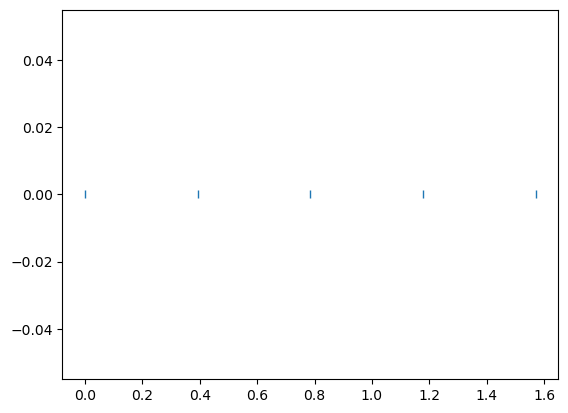

In [13]:
def romberg(f, a, b, tol=1e-8, depth=10, verbose=False):
    points.clear()

    @lru_cache()
    def g(x):
        return f(x)

    @lru_cache()
    def t(i, j):
        # whether extraplating
        if not j:
            return composite(g, a, b, k=2**i, quad=trapezoid)
        else:
            return richardson_extrapolation(t(i-1, j-1), t(i, j-1), p=2*j, q=2)


    for j in range(1, depth+1):
        if np.abs(t(j, j) - t(j-1, j-1)) < tol:
            break

    if verbose:
        for i in range(j+1):
            print(' '.join([f'{float(t(i, k))}' for k in range(i+1)]))
    return np.array([t(i, i) for i in range(j+1)])


def f(x):
    points.append(x)
    return np.sin(x)


romberg(f, 0, np.pi / 2, tol=1e-10, depth=2, verbose=True)
plt.plot(points, [0] * len(points), '|')
print(len(points))

exercises

In [14]:
# 8.1
def f(x):
    return x ** 3


print(integrate.quad(f, 0, 1)[0])
print(midpoint(f, 0, 1))
print(trapezoid(f, 0 , 1))
print((trapezoid(f, 0 , 1) - midpoint(f, 0, 1)) / 3)
print(trapezoid(f, 0 , 1) / 3  + midpoint(f, 0, 1) * 2 / 3)

0.25
0.125
0.5
0.125
0.25


In [15]:
# 8.2
m00 = composite(f, 0, 1, 1, quad=midpoint)
m10 = composite(f, 0, 1, 2, quad=midpoint)
m11 = richardson_extrapolation(m00, m10, 2, 2)
print(m11)

0.25


In [16]:
# 8.14
p = 1
richardson_extrapolation(-.88333, -.9091, 1, 2)

-0.9348700000000001

In [17]:
# 8.15
print(richardson_extrapolation(3, 3.1058, 2, 2))
richardson_extrapolation(3.4641, 3.2154, 2, 2)

3.1410666666666667


3.1325

computer problems

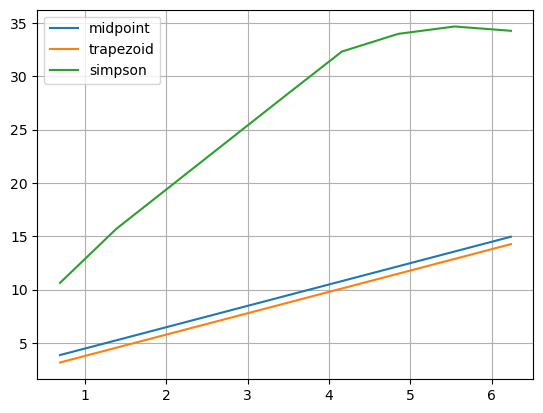

In [18]:
# 8.1
def f(x):
    return 4 / (1 + x ** 2)


for quad in [midpoint, trapezoid, simpson]:
    errors = [abs(np.pi - composite(f, 0, 1, 2 ** exponent, quad=quad)) for exponent in range(1, 10)]
    # plt.plot([1 / 2 ** exponent for exponent in range(1, 10)], errors, label=quad.__name__)
    plt.plot(- np.log([1 / 2 ** exponent for exponent in range(1, 10)]), - np.log(errors), label=quad.__name__)

# plt.axis('equal')
plt.grid(True)
plt.legend()

[3.       3.133333 3.142118 3.141586 3.141593 3.141593 3.141593]


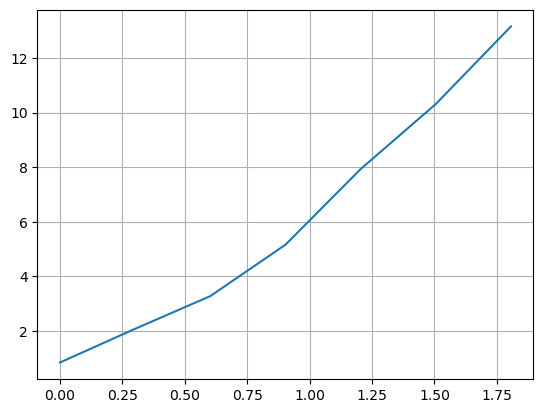

In [19]:
# (b)
vs = romberg(f, 0, 1, tol=1e-10)
print(vs)
errors = np.abs(vs - np.pi)
plt.plot(- np.log10([1 / 2 ** exponent for exponent in range(len(vs))]), - np.log10(errors))
plt.grid(True)

3.1415926535897936
3.4878684980086326e-14
21


Text(0.5, 1.0, 'Sampling points of adaptive quadrature')

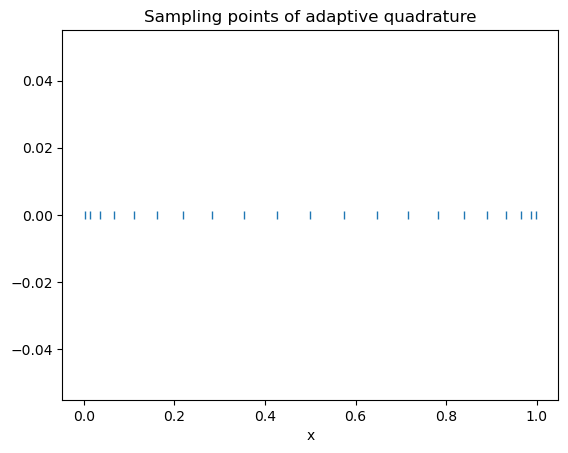

In [20]:
result, err_est = integrate.quad(f, 0, 1, epsabs=1e-10, epsrel=1e-10)
print(result)          # 3.141592653589793
print(err_est)         # ~1e-10 数量级
print(integrate.quad(f,0,1,full_output=1)[2]['neval'])  # 函数求值次数


def f_with_trace(x):
    points.append(x)
    return 4/(1+x*x)

integrate.quad(f_with_trace, 0, 1, epsabs=1e-10)

plt.plot(points, [0]*len(points), '|')
plt.xlabel('x')
plt.title('Sampling points of adaptive quadrature')

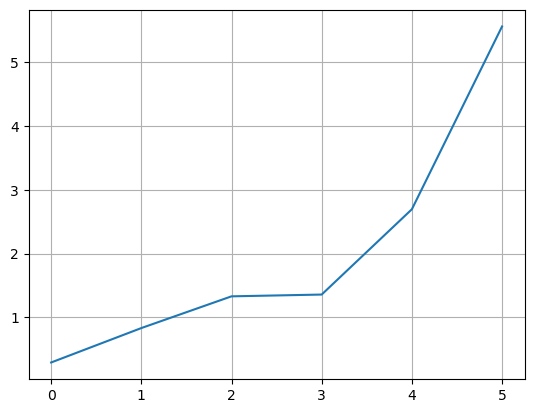

In [21]:
def monte_carlo(f, a, b, n):
    samples = a + np.random.random(n) * (b - a)
    return np.mean([f(x) for x in samples]) * (b - a)


vs = np.array([monte_carlo(f, 0, 1, 10 ** i) for i in range(6)])
errors = np.abs(vs - np.pi)
plt.plot(range(len(vs)), - np.log10(errors))
plt.grid(True)

[np.float64(3.537376553384353), np.float64(3.5663446866782427), np.float64(3.5781954202104505), np.float64(3.5829537734010235), np.float64(3.584837069781048), np.float64(3.5855739656098375), np.float64(3.585859617495014), np.float64(3.585969491894912), np.float64(3.586011478342101)]


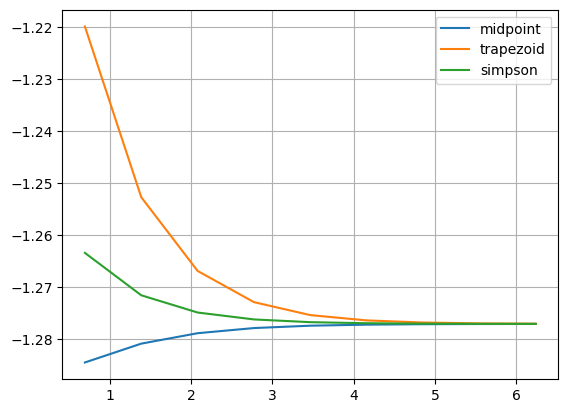

In [22]:
# 8.2
def f(x):
    points.append(x)
    return np.sqrt(x) * np.log(x) if x else 0


for quad in [midpoint, trapezoid, simpson]:
    errors = [abs(np.pi - composite(f, 0, 1, 2 ** exponent, quad=quad)) for exponent in range(1, 10)]
    # plt.plot([1 / 2 ** exponent for exponent in range(1, 10)], errors, label=quad.__name__)
    plt.plot(- np.log([1 / 2 ** exponent for exponent in range(1, 10)]), - np.log(errors), label=quad.__name__)

plt.grid(True)
plt.legend()
print(errors)

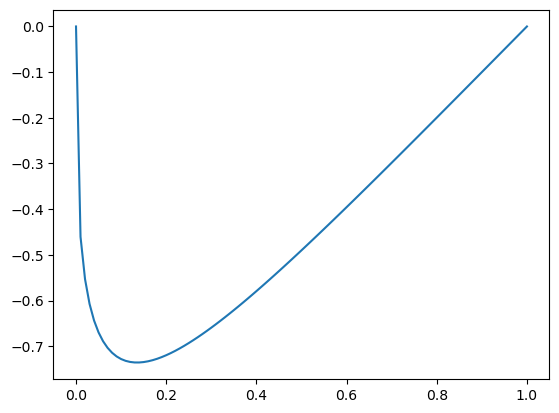

In [23]:
xs = np.linspace(0, 1, 101)
plt.plot(xs, [f(x) for x in xs])

[ 0.       -0.326753 -0.400386 -0.427101 -0.437604 -0.441767 -0.443405
 -0.444044 -0.444291 -0.444386 -0.444422]
[3.141593 3.468345 3.541979 3.568693 3.579196 3.583359 3.584998 3.585637
 3.585884 3.585979 3.586015]


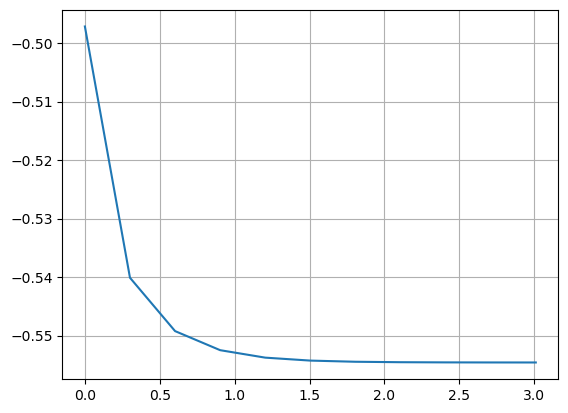

In [24]:
vs = romberg(f, 0, 1, tol=1e-10)
print(vs)
errors = np.abs(vs - np.pi)
plt.plot(- np.log10([1 / 2 ** exponent for exponent in range(len(vs))]), - np.log10(errors))
plt.grid(True)
print(errors)

[3.81907  3.67876  3.602326 3.582405 3.586426 3.586247 3.585771 3.586104]


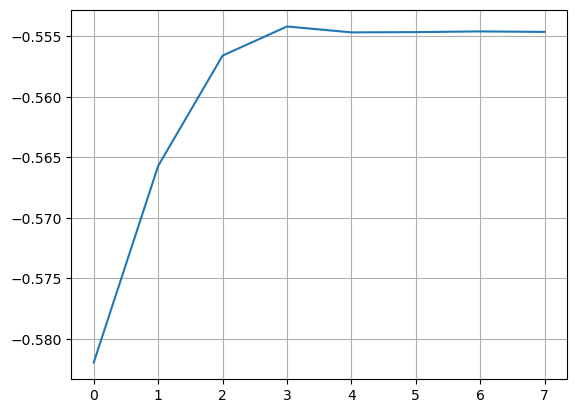

In [25]:
vs = np.array([monte_carlo(f, 0, 1, 10 ** i) for i in range(8)])
errors = np.abs(vs - np.pi)
plt.plot(range(len(vs)), - np.log10(errors))
plt.grid(True)
print(errors)

In [26]:
def integrate_and_sampling(f, intervals, **kwargs):
    points.clear()
    vs, ns = [], []
    for a, b in intervals:
        v, error, detail = integrate.quad(f, a, b, full_output=1, **kwargs)
        vs.append(v)
        ns.append(detail['neval'])
    print(sum(vs), sum(ns))
    plt.plot(points, [0] * len(points), '|')

-0.44444444444444475 315


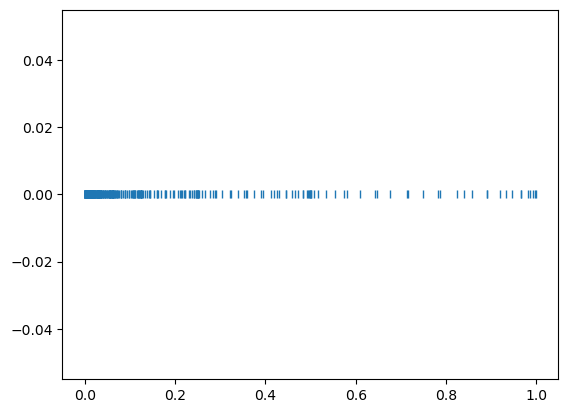

In [27]:

def f(x):
    points.append(x)
    return 0 if not x else np.sqrt(x) * np.log(x)


integrate_and_sampling(f, [[0, 1]], epsabs=1e-10)

1.6829419696157932 21
1.6829419696157975


np.float64(1.6829429056977807)

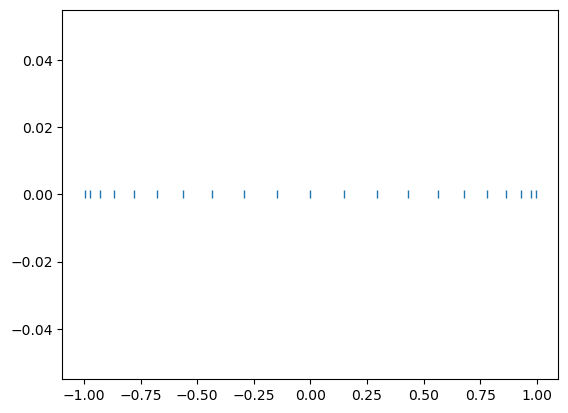

In [28]:
# 8.3
# (a)
def f(x):
    points.append(x)
    return np.cos(x)

integrate_and_sampling(f, [[-1, 1]])

print(romberg(f, -1, 1)[-1])
composite(f, -1, 1, k=10, quad=simpson)

0.29422553486074704 231
0.2942255349063664


np.float64(0.2682626641651032)

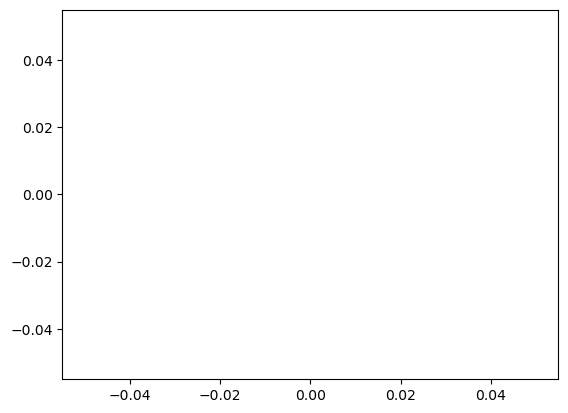

In [29]:
# (b)
def f(x):
    return 1 / (1 + 100 * x ** 2)


integrate_and_sampling(f, [[-1, 1]])

print(romberg(f, -1, 1)[-1])
composite(f, -1, 1, k=10, quad=midpoint)

1.3333333333333315 483
1.333321497637155


np.float64(1.299477195110013)

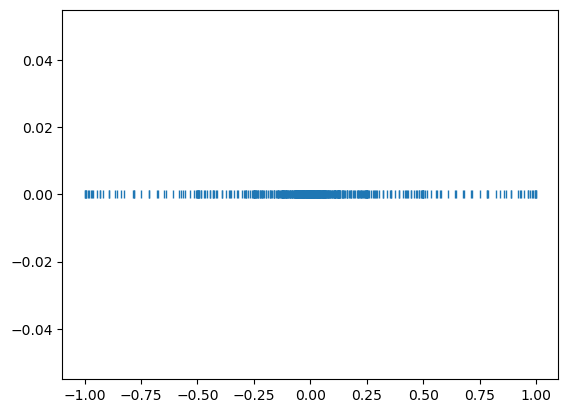

In [30]:
# (c)
def f(x):
    points.append(x)
    return np.sqrt(abs(x))


integrate_and_sampling(f, [[-1, 1]])

print(romberg(f, -1, 1)[-1])
composite(f, -1, 1, k=10, quad=trapezoid)

In [31]:
# 8.4
# (a) True
def f(x):
    return np.sqrt(x ** 3)

integrate.quad(f, 0, 1)

(0.39999999999722957, 2.8641677931471616e-09)

In [32]:
# (b) False
def f(x):
    return 1 / (1 + 10 * x ** 2)

integrate.quad(f, 0, 1)

(0.39987600505576887, 2.7338956922499114e-11)

In [33]:
# (c) False
def f(x):
    return (np.exp(-9 * x ** 2) + np.exp(-1024 * (x - 1/4) ** 2)) / np.sqrt(np.pi)

integrate.quad(f, 0, 1)

(0.19791298491716694, 4.757901155783765e-10)

In [34]:
# (d) False
def f(x):
    return 50 / np.pi / (2500 * x ** 2 + 1)

integrate.quad(f, 0, 10)

(0.4993633810764567, 6.976406124240529e-12)

In [35]:
# (e) True
def f(x):
    return 1 / np.sqrt(abs(x))

integrate.quad(f, -9, 100)

(26.000000000005958, 1.496758272878651e-11)

In [36]:
# (f) True
def f(x):
    return 25 * np.exp(-25 * x)

integrate.quad(f, 0, 10)

(1.0, 9.084355112229901e-10)

In [37]:
# (g) True
integrate.quad(np.log, 0, 1)

(-0.9999999999999999, 1.1102230246251563e-15)

0.7000000000000001 357


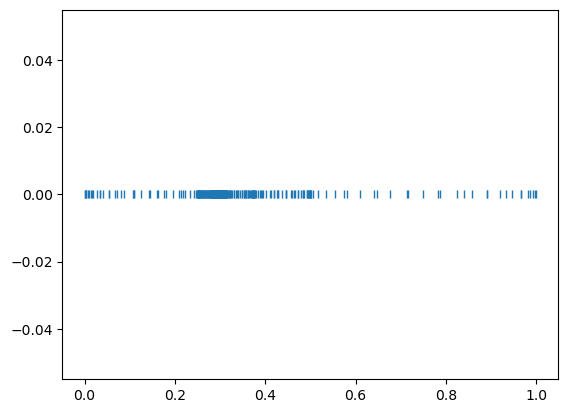

In [38]:
# 8.5
# (a)
def f(x):
    points.append(x)
    return 0 if x < .3 else 1


integrate_and_sampling(f, [[0, 1]])

0.7 42


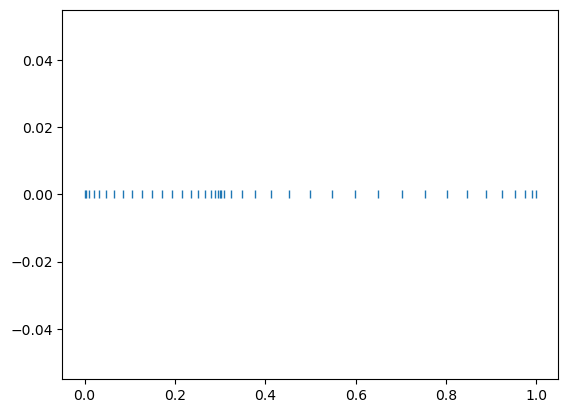

In [39]:
integrate_and_sampling(f, [[0, .3], [.3, 1]])

0.306852820409752 987


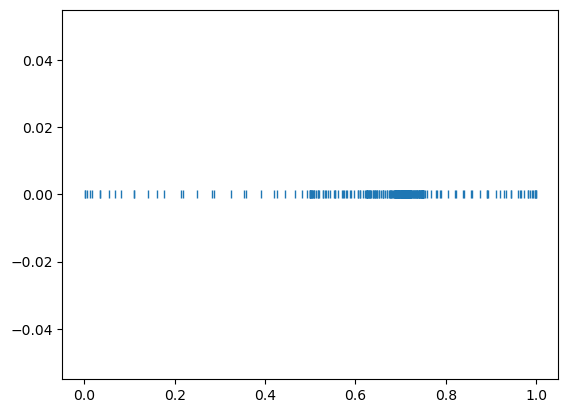

In [40]:
# (b)
def f(x):
    points.append(x)
    return 1 / (x + 2) if x < np.e - 2 else 0


integrate_and_sampling(f, [[0, 1]])

0.30685281944005466 42


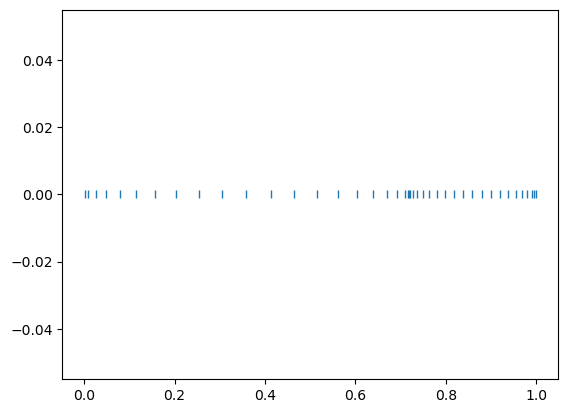

In [41]:
integrate_and_sampling(f, [[0, np.e - 2], [np.e - 2, 1]])

2.982522946116156 399


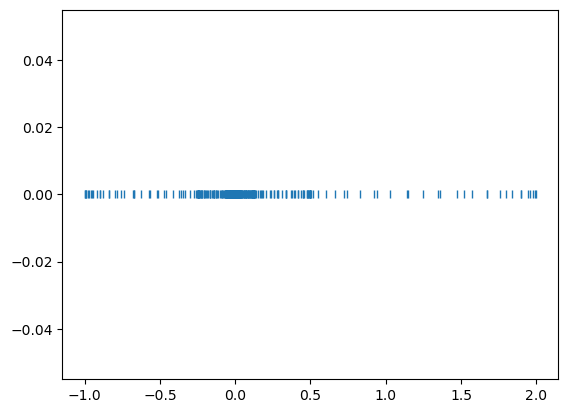

In [42]:
# (c)
def f(x):
    points.append(x)
    return np.exp(x) if x < 0 else np.exp(1-x)

integrate_and_sampling(f, [[-1, 2]])

2.9825229461161604 42


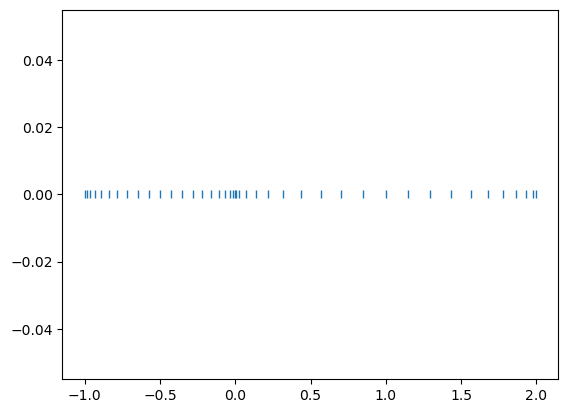

In [43]:
integrate_and_sampling(f, [[-1, 0], [0, 2]])

29.681953485822337 483


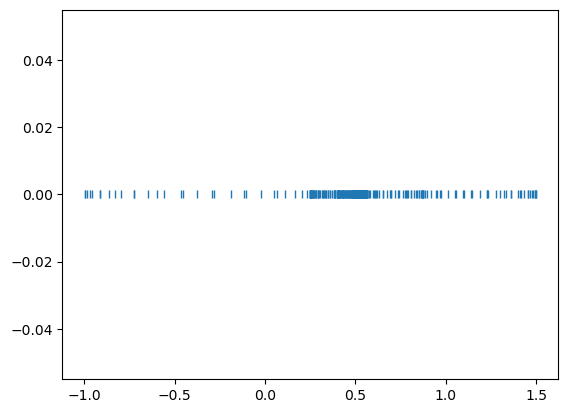

In [44]:
# (d)
def f(x):
    points.append(x)
    return np.exp(10 * x) if x < .5 else np.exp(10 * (1-x))

integrate_and_sampling(f, [[-1, 1.5]])

29.681953485822437 42


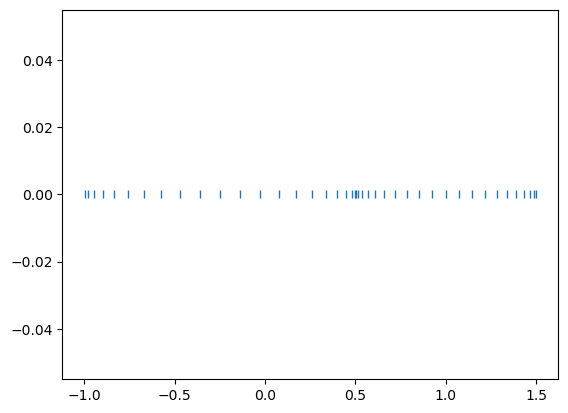

In [45]:
integrate_and_sampling(f, [[-1, .5], [.5, 1.5]])

0.5683098861837906 21


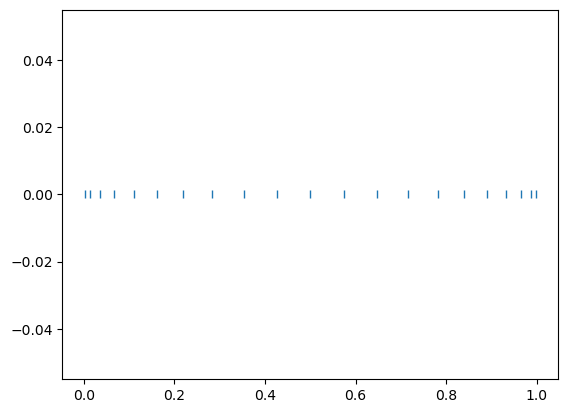

In [46]:
# (e)
def f(x):
    points.append(x)
    return np.sin(np.pi * x) if x < .5 else np.sin(np.pi * x) ** 2

integrate_and_sampling(f, [[0, 1]])

0.5683098861837906 42


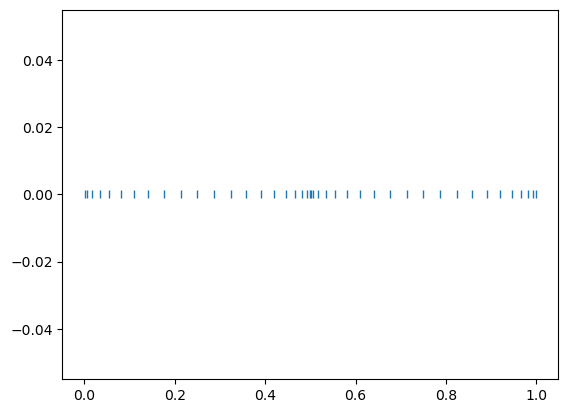

In [47]:
integrate_and_sampling(f, [[0, .5], [.5, 1]])

In [48]:
# 8.6
# (a)
for k in range(21):
    def f(x):
        return x ** k * np.exp(x - 1)
    
    print(k, integrate.quad(f, 0, 1)[0])

0 0.6321205588285578
1 0.36787944117144233
2 0.2642411176571154
3 0.20727664702865392
4 0.17089341188538432
5 0.1455329405730786
6 0.12680235656152847
7 0.11238350406930085
8 0.10093196744559328
9 0.09161229298966059
10 0.08387707010339417
11 0.07735222886266423
12 0.07177325364802957
13 0.0669477025756157
14 0.06273216394138016
15 0.0590175408792978
16 0.05571934593123561
17 0.052771119168994775
18 0.050119854958094276
19 0.04772275579620911
20 0.04554488407581806


In [49]:
# (b)
f = 1 - 1 / np.e
for k in range(1, 21):
    f = 1 - k * f
    print(k, f)

1 0.36787944117144233
2 0.26424111765711533
3 0.207276647028654
4 0.17089341188538398
5 0.14553294057308008
6 0.1268023565615195
7 0.11238350406936348
8 0.10093196744509214
9 0.09161229299417073
10 0.0838770700582927
11 0.07735222935878028
12 0.07177324769463667
13 0.06694777996972334
14 0.06273108042387321
15 0.059033793641901866
16 0.05545930172957014
17 0.05719187059730757
18 -0.029453670751536265
19 1.559619744279189
20 -30.19239488558378


In [50]:
# (c)
n, f = 25, 0
while n > 0:
    f = (1 - f) / n
    n -= 1
    if n <= 20:
        print(n, f)

20 0.045544889892715976
19 0.0477227555053642
18 0.050119854973401885
17 0.05277111916814434
16 0.05571934593128563
15 0.05901754087929465
14 0.06273216394138036
13 0.06694770257561569
12 0.07177325364802957
11 0.0773522288626642
10 0.08387707010339417
9 0.09161229298966059
8 0.10093196744559327
7 0.11238350406930084
6 0.12680235656152844
5 0.1455329405730786
4 0.17089341188538426
3 0.20727664702865395
2 0.26424111765711533
1 0.36787944117144233
0 0.6321205588285577


0.042347520940822635 63


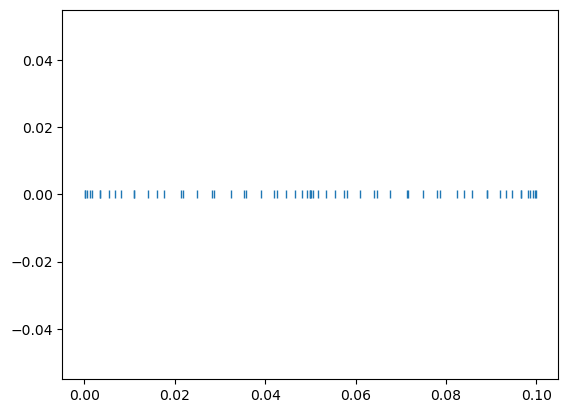

In [51]:
# 8.7
b = 100
a = (3 - 2 * np.sqrt(2)) / b
k = b * np.sqrt(1 - a * b)


def f(x):
    points.append(x)
    return 4 * np.pi * np.sqrt(a) * np.sqrt(1 - k * x ** 2)


integrate_and_sampling(f, [[0, 1 / np.sqrt(b)]])

In [52]:
s = np.acos(np.sqrt(k / b))
np.pi * np.sqrt(a / k) * (np.pi + np.sin(2 * s) - 2 * s)

np.float64(0.042347520940824335)

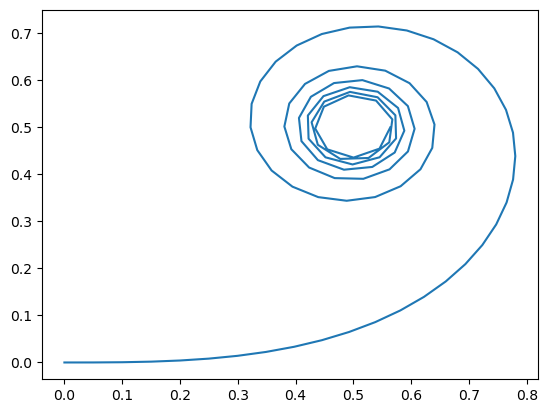

In [53]:
# 8.8
def c(x):
    return np.cos(np.pi * x ** 2 / 2)


def s(x):
    return np.sin(np.pi * x ** 2 / 2)


cs = [integrate.quad(c, 0, x)[0] for x in np.linspace(0, 5, 101)]
ss = [integrate.quad(s, 0, x)[0] for x in np.linspace(0, 5, 101)]
plt.plot(cs, ss)

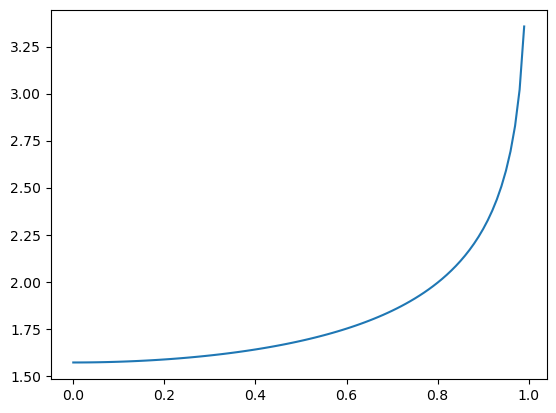

In [54]:
# 8.9
from functools import partial

def f(t, x):
    return 1 / np.sqrt(1 - x ** 2 * np.sin(t) ** 2)


plt.plot(np.linspace(0, 1, 101)[:-1], [integrate.quad(partial(f, x=x), 0, np.pi / 2)[0] for x in np.linspace(0, 1, 101)[:-1]])

In [55]:
# 8.10
def g(t, x):
    return t ** (x - 1)


def f(t, x):
    return g(t, x) * np.exp(- t)

b = 100
print(composite(partial(f, x=5), 0, b, k=b, quad=simpson))
integrate.quad(partial(f, x=5), 0, b)[0]

23.9989681443282


23.999999999999993

In [56]:
# Gauss-Laguerre quadrature 5
xs = [
    0.263560,
    1.413403,
    3.596426,
    7.085810,
    12.640800,
]

ws = [
    0.521756,
    0.398667,
    0.0759424,
    0.0036118,
    0.00002337,
]



def gauss_laguerre_5_points(f):
    return sum(w * f(x) for x, w in zip(xs, ws))


gauss_laguerre_5_points(partial(g, x=5))

24.000100081143863

In [57]:
integrate.quad(partial(f, x=5), 0, np.inf)[0]

24.0

In [58]:
special.gamma(5)

np.float64(24.0)

In [59]:
import math
math.factorial(4)

24

In [60]:
# 8.11
def g(x):
    return x ** 3 / (np.exp(x) - 1) * np.exp(x)


def f(x):
    return g(x) * np.exp(- x)


b = 100
print(composite(f, 0, b, k=b, quad=midpoint))
integrate.quad(f, 0, b)[0]

6.49758523560015


6.493939402266821

In [61]:
gauss_laguerre_5_points(g)

np.float64(6.494326886738259)

In [62]:
def ff(x):
    return x ** 3 / (np.exp(x) - 1)

integrate.quad(ff, 0, np.inf)[0]

C:\Users\chuny\AppData\Local\Temp\ipykernel_22776\214193590.py:2: RuntimeWarning: overflow encountered in exp
  return x ** 3 / (np.exp(x) - 1)


6.49393940226683

In [63]:
# 8.12
# (a)
def f(x):
    return np.exp(- x ** 2) * np.cos(x)

a, b = -100, 100
print(composite(f, a, b, k=b-a, quad=midpoint))

1.3787331604272681


In [64]:
np.sqrt(np.pi) * np.exp(- .25)

np.float64(1.380388447043143)

In [65]:
a, b = -100, 100
integrate.quad(f, a, b)[0]

1.3803884470431431

In [66]:
xs = [
    -2.0201828705,
    -0.9585724646,
    0,
    0.9585724646,
    2.0201828705,
]

ws = [
    0.0199532421,
    0.3936193232,
    0.9453087205,
    0.3936193232,
    0.0199532421,
]

def gauss_hermite_5_points(f):
    return sum(w * f(x) for x, w in zip(xs, ws))


gauss_hermite_5_points(np.cos)

np.float64(1.38039007597935)

In [67]:
integrate.quad(f, -np.inf, np.inf)[0]

1.3803884470431418

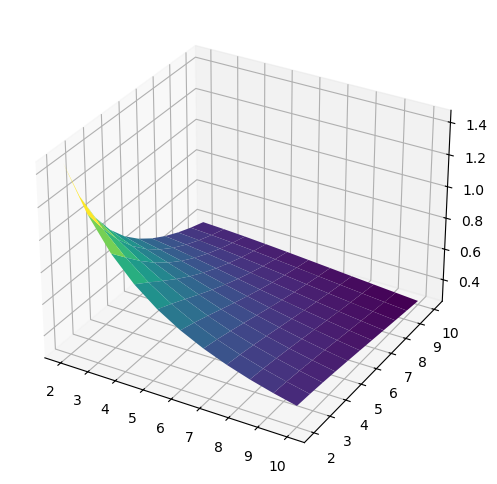

In [68]:
# 8.13
def f(y, x, y_head, x_head):
    return 1 / np.sqrt((x_head - x) ** 2 + (y_head - y) ** 2)


X, Y = np.meshgrid(np.linspace(2, 10, 11), np.linspace(2, 10, 11))

Z = np.zeros_like(X)
for i in range(len(X)):
    for j in range(len(X[0])):
        Z[i, j] = integrate.dblquad(partial(f, x_head=X[i, j], y_head=Y[i, j]), -1, 1, lambda x: -1, lambda x: 1)[0]


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

In [69]:
# 8.14
# (a)
def f(y, x):
    return np.exp(- x * y)

integrate.dblquad(f, 0, 1, lambda x: 0, lambda x: 1)[0]

0.7965995992970532

In [70]:
integrate.dblquad(f, 0, 1, lambda x: 0, lambda x: np.sqrt(1 - x ** 2))[0]

0.6751670568500855

-0.4444444444444433
10463


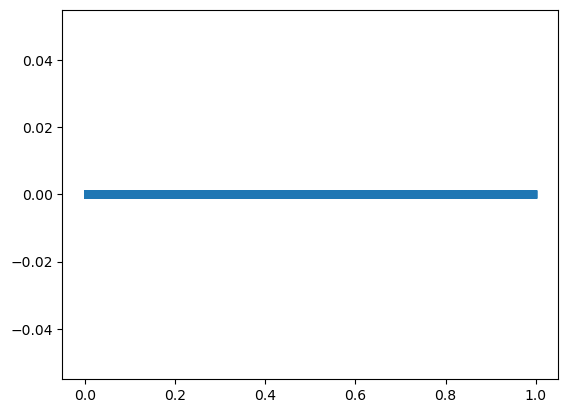

In [71]:
# 8.15
def adapt_integrate(f, a, b, quad, k=2):
    points.clear()

    @lru_cache()
    def g(x):
        return f(x)
    
    i_est = monte_carlo(g, a, b, n=10)

    @lru_cache()
    def adaptquad(a, b):
        i1 = composite(g, a, b, k, quad)
        i2 = composite(g, a, b, 2 * k, quad)
        m = a + (b - a) / 2
        if m <= a or m >= b:
            Warning('reach machine precision!')
            return i2
        
        if i_est + (i2 - i1) == i_est:
            return i2
        else:
            return adaptquad(a, m) + adaptquad(m, b)
    
    return adaptquad(a, b)


def f(x):
    points.append(x)
    return np.sqrt(x) * np.log(x) if x else 0


print(adapt_integrate(f, 0, 1, simpson))
plt.plot(points, [0] * len(points), '|')
print(len(points))

In [72]:
# 8.17
def generate_ab(n):
    A = np.zeros((n, n))
    ws = 1 / ((n - 1) / 2) * np.ones(n) * 2 / 6
    ws[1::2] = ws[1::2] * 2
    ws[0], ws[-1] = ws[0] / 2, ws[-1] / 2
    for i in range(n):
        for j in range(n):
            s, t = 1 / (n-1) * i, 1 / (n-1) * j
            A[i, j] = ws[j] * np.sqrt(s ** 2 + t ** 2)

    ss = np.arange(n) / (n-1)
    return A, ((ss ** 2 + 1) ** 1.5 - ss ** 3) / 3


for n in range(3, 16, 2):
    print(la.solve(*generate_ab(n)))

[0.07498  0.458382 1.083235]
[0.044818 0.212392 0.599311 0.718473 1.032878]
[0.029471 0.143435 0.371293 0.52911  0.504089 0.904711 0.910806]
[ 0.021671  0.109738  0.236834  0.509297 -0.334829  1.346094 -0.725252
  1.288214  0.611492]
[ 0.017094  0.089146  0.157094  0.527377 -1.411821  2.859083 -7.852315
  5.816723 -7.14966   2.679165 -0.389644]
[  0.014106   0.075125   0.107801   0.545825  -2.525162   5.368629
 -25.114824  25.093277 -67.203336  33.572236 -41.021374   8.789588
  -4.279019]
[   0.012005    0.064934    0.075861    0.556566   -3.543483    8.532376
  -54.592481   72.907216 -293.203905  226.149706 -510.633748  207.257703
 -222.979293   37.318777  -20.407016]


In [73]:
for n in range(3, 16, 2):
    print(np.linalg.cond(generate_ab(n)[0]))

86.68741428101131
18333.871519110267
3310302.694207163
532486547.82751673
81511803586.36334
12159314946245.55
1765782283195808.8


In [74]:
for n in range(3, 16, 2):
    print(la.lstsq(*generate_ab(n), cond=1e-8)[0])

[0.07498  0.458382 1.083235]
[0.044818 0.212392 0.599311 0.718473 1.032878]
[0.029471 0.143435 0.371293 0.52911  0.504089 0.904711 0.910806]
[0.021951 0.108337 0.264015 0.434524 0.152635 0.871611 0.34964  0.963272
 0.934462]
[0.017567 0.086623 0.212735 0.340795 0.188631 0.612642 0.451868 0.829865
 0.317775 1.099837 0.761394]
[0.014867 0.071126 0.195155 0.244658 0.332322 0.442188 0.245441 0.78662
 0.459274 0.808452 0.374685 1.182849 0.627855]
[ 0.012459  0.062323  0.143175  0.267266 -0.008674  0.541715  0.286849
  0.474682  0.322294  0.906939  0.48856   0.832403  0.376448  1.192662
  0.658287]


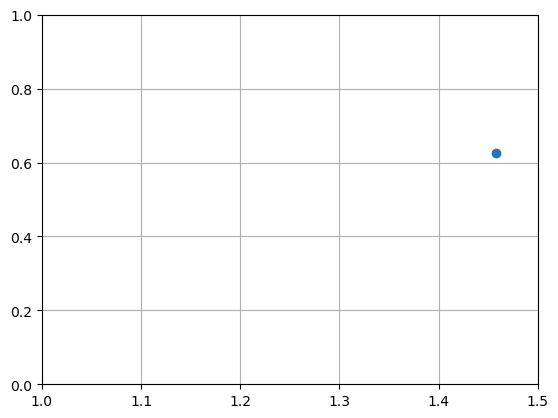

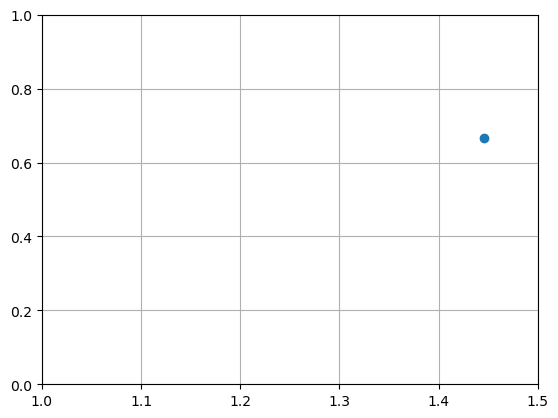

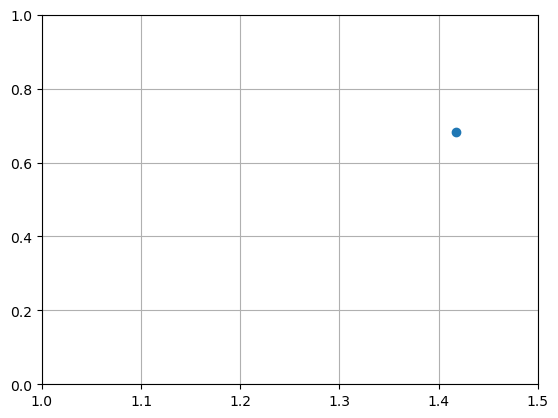

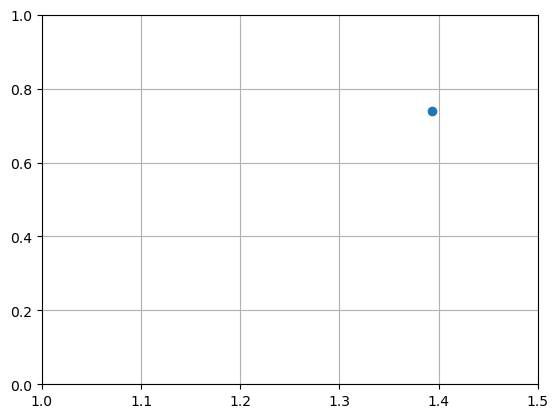

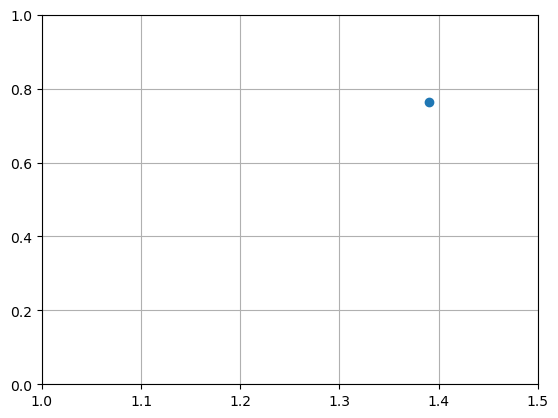

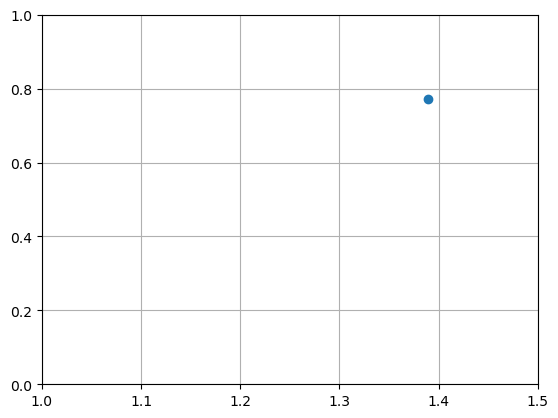

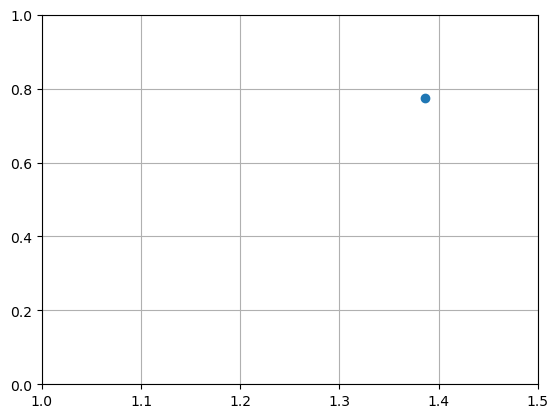

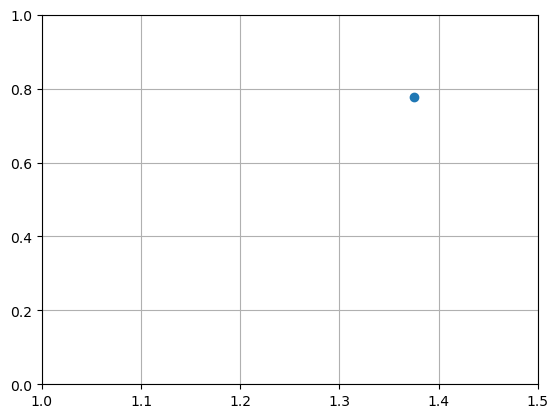

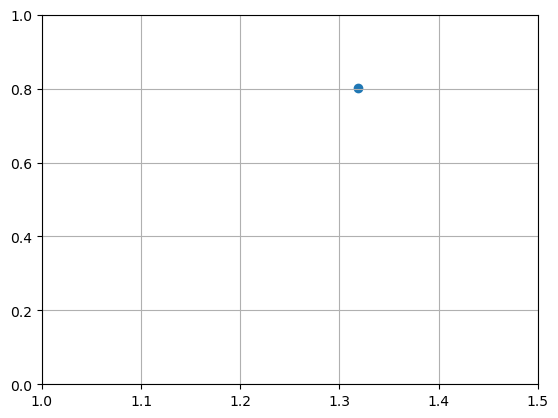

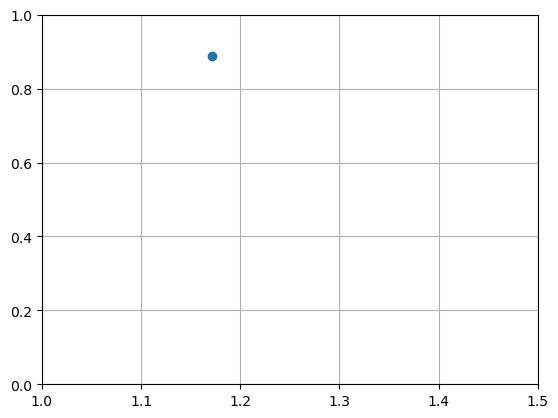

In [75]:
n = 7
A, b = generate_ab(n)
for mu in [10 ** i for i in range(-10, 0)]:
    plt.figure()


    A_aug = np.vstack([A, np.sqrt(mu) * np.eye(n)])
    b_aug = np.concatenate([b, np.zeros(n)])

    x = la.lstsq(A_aug, b_aug)[0]
    plt.scatter(la.norm(x), la.norm(x - np.arange(n) / (n-1)))
    plt.xlim(1, 1.5)
    plt.ylim(0, 1)
    plt.grid(True)

In [76]:
def f(x):
    return (b - A @ x) @ (b - A @ x)

opt.minimize(f, x0=np.zeros(n),bounds=[(0, None) for _ in range(n)])

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 2.538395967653328e-07
        x: [ 1.147e-03  1.605e-01  1.878e-01  6.105e-01  4.259e-01
             1.095e+00  3.344e-01]
      nit: 5
      jac: [-3.685e-06 -3.974e-07  2.603e-06  5.552e-06  1.635e-06
            -2.077e-07 -1.047e-06]
     nfev: 64
     njev: 8
 hess_inv: <7x7 LbfgsInvHessProduct with dtype=float64>

In [77]:
CA = np.eye(n) - np.diag(np.ones(n-1), -1)
ub = [np.inf] * n
lb = np.zeros(n)

linear_constraint = opt.LinearConstraint(CA, lb, ub)
opt.minimize(f, np.zeros(n), constraints=linear_constraint)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 4.584053125895145e-07
           x: [ 1.583e-02  1.050e-01  3.699e-01  5.743e-01  6.740e-01
                8.406e-01  8.406e-01]
         nit: 7
         jac: [-5.514e-06 -1.982e-06  2.698e-06  5.456e-06  9.785e-07
               -3.129e-06 -2.218e-06]
        nfev: 56
        njev: 7
 multipliers: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
                0.000e+00  4.557e-07]

In [ ]:
# 8.18
# (a)
ts = range(6)
ys = [1, 2.7, 5.8, 6.6, 7.5, 9.9]

def generate_a(n):
    return np.vander(ts, n, increasing=True)


for n in range(1, 7):
    A = generate_a(n)
    dp = Polynomial(la.lstsq(A, ys)[0]).deriv()
    print(dp(ts))

[0. 0. 0. 0. 0. 0.]
[1.705714 1.705714 1.705714 1.705714 1.705714 1.705714]
[2.178929 1.989643 1.800357 1.611071 1.421786 1.2325  ]
[3.155688 2.110847 1.493783 1.304497 1.542989 2.209259]
[0.119974 2.839418 2.16164  0.63664  0.814418 5.244974]
[-3.178333  3.88      1.821667  0.296667  1.855     1.946667]


In [ ]:
# (b)
p = interpolate.CubicSpline(ts, ys, bc_type='natural')
p(ts, 1)

array([1.165072, 2.769856, 2.155502, 0.308134, 1.711962, 2.744019])

In [96]:
# (c) smoothing spline
for s in .01, .1, 1:
    p = interpolate.UnivariateSpline(ts, ys, s=s)
    print(p(ts, 1))

[-0.460936  3.161664  2.039065  0.445118  1.405247  3.671028]
[0.357943 2.848257 2.083667 0.587638 1.174693 4.135895]
[2.997598 2.138764 1.557733 1.254506 1.474495 2.463111]


In [97]:
# (d)
p = interpolate.PchipInterpolator(ts, ys)
p(ts, 1)

array([1.      , 2.195833, 1.271795, 0.847059, 1.309091, 3.15    ])